### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
from astropy.constants import c, k_B, R_earth
import src.read_database as read_database
import src.map_properties as map_properties
import src.satellite_properties as satellite_properties
import src.store_FOV_indices as store_FOV_indices
import src.Friis as Friis
import src.power_3D_cube as power_3D_cube
import time
%matplotlib inline   

In [2]:
start_time=time.time()

### Read FM Transmitter Database 

In [3]:
n = str(input("Enter the number of countries to include"))

Enter the number of countries to includeAll


In [4]:
df = read_database.read_FM_database(countries=read_database.get_countries(n))

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)


### Define frequency range  

In [5]:
freq_range = read_database.get_freq_range()

Please enter the minimum value of the frequency range (in MHz): 55
Please enter the maximum value of the frequency range (in MHz): 110
Please enter the resolution of the frequency (in MHz): 0.244


In [6]:
freq_range

array([ 55.   ,  55.244,  55.488,  55.732,  55.976,  56.22 ,  56.464,
        56.708,  56.952,  57.196,  57.44 ,  57.684,  57.928,  58.172,
        58.416,  58.66 ,  58.904,  59.148,  59.392,  59.636,  59.88 ,
        60.124,  60.368,  60.612,  60.856,  61.1  ,  61.344,  61.588,
        61.832,  62.076,  62.32 ,  62.564,  62.808,  63.052,  63.296,
        63.54 ,  63.784,  64.028,  64.272,  64.516,  64.76 ,  65.004,
        65.248,  65.492,  65.736,  65.98 ,  66.224,  66.468,  66.712,
        66.956,  67.2  ,  67.444,  67.688,  67.932,  68.176,  68.42 ,
        68.664,  68.908,  69.152,  69.396,  69.64 ,  69.884,  70.128,
        70.372,  70.616,  70.86 ,  71.104,  71.348,  71.592,  71.836,
        72.08 ,  72.324,  72.568,  72.812,  73.056,  73.3  ,  73.544,
        73.788,  74.032,  74.276,  74.52 ,  74.764,  75.008,  75.252,
        75.496,  75.74 ,  75.984,  76.228,  76.472,  76.716,  76.96 ,
        77.204,  77.448,  77.692,  77.936,  78.18 ,  78.424,  78.668,
        78.912,  79.

In [7]:
df = read_database.extract_common_freq(df, freq_range)


### Define resolution of the Healpy map

In [8]:
print('----------- Resolution of the map -----------')

# The default value of nside is 16
nside = int(input("Enter the NSIDE of the healpy map"))
npix, pix_array, phi, theta = map_properties.get_map(nside)

print(f"The number of pixels for the given NSIDE: {(hp.nside2npix(nside))}")
print(f"Approximate resolution in degrees for given nside {np.degrees(hp.nside2resol(nside)):.2f}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.2f} square degrees")

----------- Resolution of the map -----------
Enter the NSIDE of the healpy map32
The number of pixels for the given NSIDE: 12288
Approximate resolution in degrees for given nside 1.83
Pixel area: 3.36 square degrees


In [9]:
beam_pattern=str(input('Enter desired beam pattern:'))

Enter desired beam pattern:cos square


### Allocate pixel number to the Latitude and Longitude of each FM transmitter in the database

In [10]:
df, pixel_indices = read_database.allocate_pixel_num(nside, df)


### Define altitude of the satellite orbit 

In [11]:
altitudes = satellite_properties.get_altitudes() #input format: alt1 alt2 alt3 (example:650 705 36000)

Enter desired altitudes:650 705 35900


### Calculation of Elevation angle

In [12]:
elev_angle = satellite_properties.calc_elev_angle(npix, phi, theta, altitudes)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  elev_ang[k, i, j] = -(np.degrees(np.arctan((B - cos_theta_j) / sin_y_ang)))
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:41: RuntimeWarning: invalid value encountered in arccos
  y_ang = np.arccos(x_ang)


###  Calculation of Field of view (FOV) and Radius of the FOV of the satellite

In [13]:
FOV = satellite_properties.calc_field_of_view(altitudes)

The Field of view of the satellite at a height of 650.00 km is 2.27 radians
The Field of view of the satellite at a height of 705.00 km is 2.24 radians
The Field of view of the satellite at a height of 35900.00 km is 0.30 radians


In [14]:
Central_angle, Rad_of_FOV = satellite_properties.calc_central_angle(altitudes)

The Radius of the Field of View for a height of 650.00 km in radians is 0.43
The Radius of the Field of View for a height of 705.00 km in radians is 0.45
The Radius of the Field of View for a height of 35900.00 km in radians is 1.42


# Create power cube 

In [15]:
disc = store_FOV_indices.get_disc(nside, phi, theta, Rad_of_FOV, pix_array)

In [16]:
pix_common = store_FOV_indices.get_common_pix(pix_array, Rad_of_FOV, disc, df)

In [17]:
found_common = store_FOV_indices.get_common_Tx(pixel_indices, pix_common, Rad_of_FOV)

In [18]:
Rx_Power_in_Kelvin = Friis.calc_Friis(df, altitudes)[2]
# print(df)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:30: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBm[j][i]= 10.*np.log10( Rx_Power[j][i])+30
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:32: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBW[j][i]= 10.*np.log10( Rx_Power[j][i])


In [19]:
df_fov = power_3D_cube.get_dataframe_fov(Rx_Power_in_Kelvin, df, found_common, Rad_of_FOV, elev_angle,beam_pattern)

In [20]:
power_output = power_3D_cube.get_power_output(npix, Rad_of_FOV, freq_range, df_fov)

In [21]:
end_time=time.time()

In [22]:
execution_time = end_time - start_time

print(f"Execution time: {execution_time/3600} hours")

Execution time: 1.9723363843891355 hours


In [23]:
power_output[:,:,:]+=300

In [24]:
# np.save('/home/saurabhs/Documents/Yogen_starfire/skymodels/elev_angle.npy',elev_angle)

In [25]:
# np.save('/home/saurabhs/Documents/Yogen_starfire/skymodels/power_output.npy',power_output)

## Plot  Spectrum 

<b> The first index represents altitude of the satellite <b>\
<b> The second index represents location of the satellite(pixel number) <b>\
<b> The third index represents range of frequencies <b>

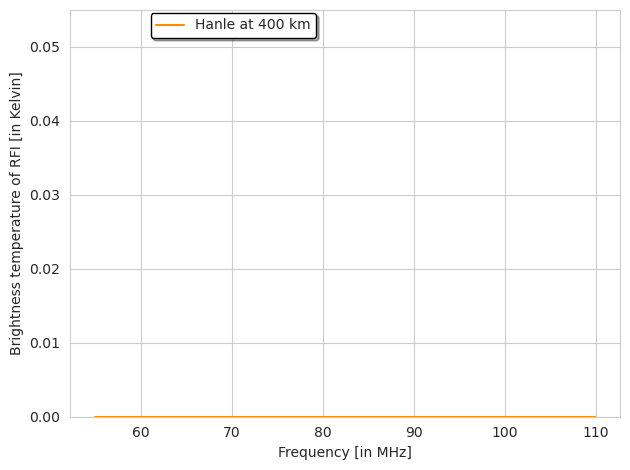

In [26]:
# # sns.set_style("darkgrid")
# sns.set(rc={"xtick.bottom": True, "ytick.left": True,
#             "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
munpix=hp.ang2pix(nside, 79.00119940706838,32.79051336948348,lonlat=True)
plt.plot(freq_range,np.zeros(len(freq_range)), label='Hanle at 400 km', color='darkorange') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
# plt.yscale('log')
plt.ylim(bottom=0)
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/IC_RFIspec.pdf',dpi=600,bbox_inches='tight')


# Orbit evaluation

In [27]:
# Predefine constants
deltaT=8.640869140625
thresholdFOM=54 # threshold FOM for radio quiet zones
tot_band=freq_range[-1]-freq_range[0]

54.89999999999995

## RFI assessment in polar orbit

### FOM map for landsat (alt: 705 km)

In [37]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]>300])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band
    

In [38]:
FOM_map[FOM_map<0]

array([], dtype=float64)

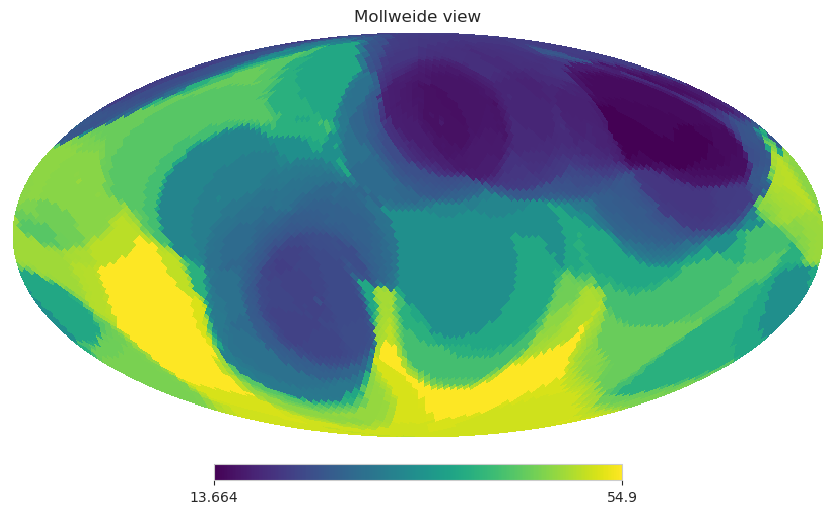

In [39]:
hp.mollview(FOM_map,flip='geo',norm='hist',cmap='viridis')

In [30]:
polon=np.load('../ground_tracks/polar_GT/longitude.npy')
polat=np.load('../ground_tracks/polar_GT/latitude.npy')
polsunlit=np.load('../ground_tracks/polar_GT/sunlit.npy')

In [31]:
saalon=np.linspace(-90,40,100)
saalat=np.linspace(-50,0,100)
blon,blat=np.meshgrid(saalon,saalat)
bpix=hp.ang2pix(nside,blon,blat,lonlat=True)

In [32]:
FOM_map[bpix]=0 # Set SAA pixels to 0 FOM

In [40]:
FOMtime1=np.zeros(55) # define FOM bins of width 1 MHz 
for i in range(len(polat)): # i is a day of OP
    for j in range(len(polat[0])): # j is each ground track coord of that sliced day. (10000 points)
        orbpix=hp.ang2pix(nside,polon[i,j],polat[i,j],lonlat=True) # get pixel of coord
        fomval=int(FOM_map[orbpix]) # obtain FOM value in integer format
        if polsunlit[i,j]==True: 
            FOMtime1[fomval]+=0 # Does not count the FOM if it is sunlit.
        else:
            FOMtime1[fomval]+=deltaT # Adds deltaT if the point is not sunlit, as it spends deltaT time at that
                                     # point.

In [41]:
np.sum(FOMtime1)/3600

2964.05813937717

In [42]:
(FOMtime1[-1])/3600 # Total time spent in highest FOM bin per year in hours

241.35387654622397

### Max uninterrupted RFI free time per day

In [43]:
dailymax=[]
dailytotal=[]
for h in range(polat.shape[0]):
    oneslice=polsunlit[h,:]
    count=0
    foms=[]
    for k in range(len(oneslice)):
        if oneslice[k-1]==oneslice[k]==False:
            pix=hp.ang2pix(nside,polon[h,k],polat[h,k],lonlat=True)
            foms.append(int(FOM_map[pix]))
            valz=[]
            for i in range(len(foms)-1):
                if foms[i+1]==foms[i]>=thresholdFOM:
                    count+=1
                else:
                    valz.append(count*(deltaT/60))
                    count=0
    dailymax.append(max(valz)) 
    dailytotal.append(sum(valz))



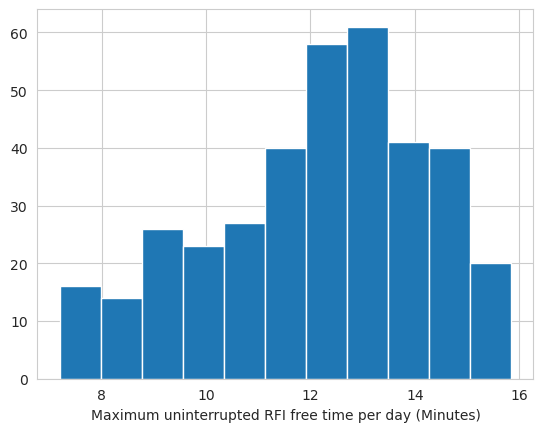

In [44]:
from src2.FDrule import FDrule
sns.set_style('whitegrid')
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/polar_unint.pdf',dpi=600,bbox_inches='tight')
plt.show()

### RFI lines over good regions

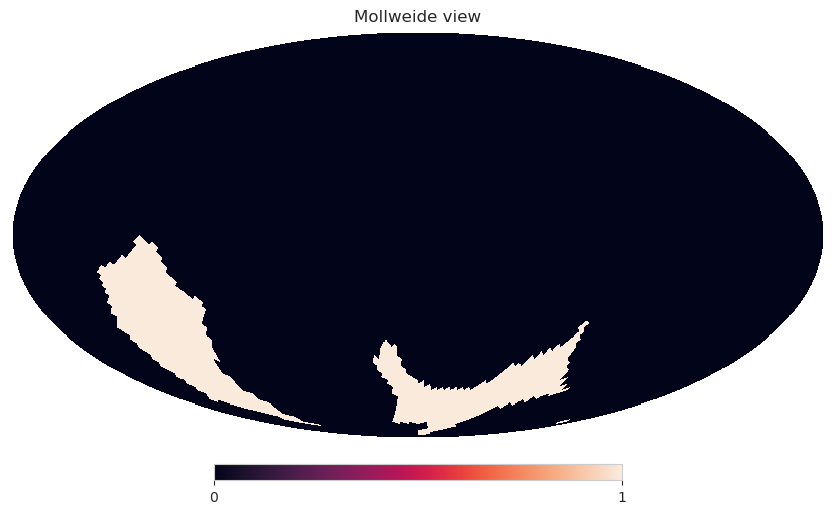

In [79]:
goodpix=np.where(FOM_map>54)
newfom=np.zeros(hp.nside2npix(nside))
newfom[goodpix]+=1
hp.mollview(newfom,flip='geo')

In [80]:
goodpix=np.array(goodpix)

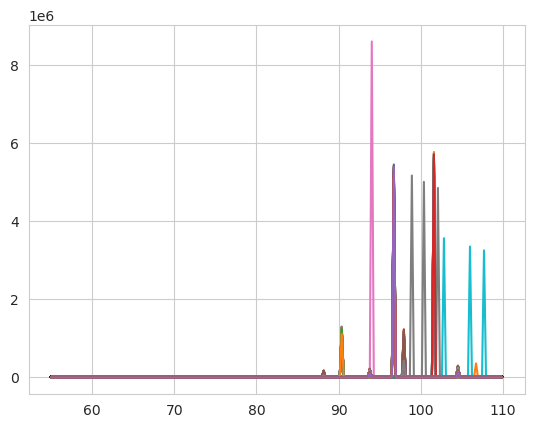

In [81]:
goodpix=np.array(goodpix)[0]
num=[]
for i in goodpix:
    lines=power_output[1,i,:]
    num.append(np.sum(lines>300))
    plt.plot(freq_range,lines)
plt.show()

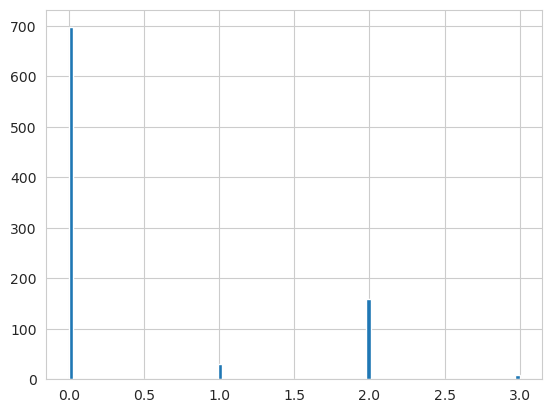

In [82]:
plt.hist(num,bins=100)
plt.show()

In [85]:
num=np.array(num)

In [91]:
len(num[num==0])

697

In [48]:
OWFOM=np.zeros(hp.nside2npix(nside))
time=np.zeros(np.shape(OWFOM))
for i in range(len(polat)):
    for j in range(len(polat[0])):
        pix=hp.ang2pix(nside,polon[i,j],polat[i,j],lonlat=True)
        time[pix]+=deltaT/3600
        

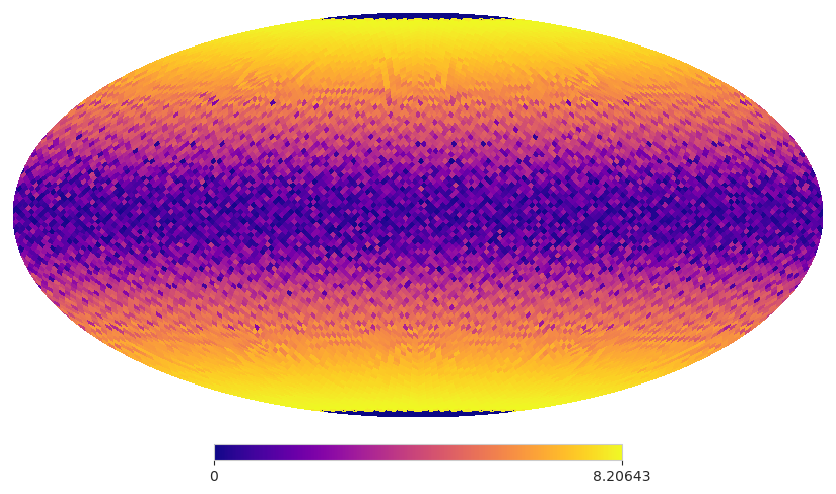

In [49]:
hp.mollview(time,flip='geo',cmap='plasma',norm='hist',title='')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/timeHM_polar.pdf',dpi=600)
plt.show()


In [ ]:
np.max(power_output[0,:,:])*1e-10

## RFI assessment in equatorial orbit

### FOM map for AstroSAT (alt: 650km)

In [ ]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[0,i,:]>300])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band
    

In [ ]:
FOM_map[bpix]=0

In [ ]:
equilon=np.load('../ground_tracks/equi_GT/longitude.npy')
equilat=np.load('../ground_tracks/equi_GT/latitude.npy')
equisunlit=np.load('../ground_tracks/equi_GT/sunlit.npy')

In [ ]:


FOMtime=np.zeros(55)
for i in range(len(equilat)):
    for j in range(len(equilat[0])):
        orbpix=hp.ang2pix(nside,equilon[i,j],equilat[i,j],lonlat=True)
        fomval=int(FOM_map[orbpix])
        if equisunlit[i,j]==True:
            FOMtime[fomval]+=0
        else:
            FOMtime[fomval]+=deltaT
            
fomvals=np.linspace(0,55,55)
plt.plot(fomvals,(FOMtime/3600))
plt.show()

# dailymax=[]
# dailytotal=[]
# for h in range(equilat.shape[0]):
#     oneslice=equisunlit[h,:]
#     count=0
#     foms=[]
#     for k in range(len(oneslice)):
#         if oneslice[k-1]==oneslice[k]==False:
#             pix=hp.ang2pix(nside,equilon[h,k],equilat[h,k],lonlat=True)
#             foms.append(int(FOM_map[pix]))
#             valz=[]
#             for i in range(len(foms)-1):
#                 if foms[i+1]==foms[i]>=thresholdFOM:
#                     count+=1
#                 else:
#                     valz.append(count*(deltaT/60))
#                     count=0
#     dailymax.append(max(valz))            
#     dailytotal.append(sum(valz))


In [96]:
FOMtime[-1]/3600

NameError: name 'FOMtime' is not defined

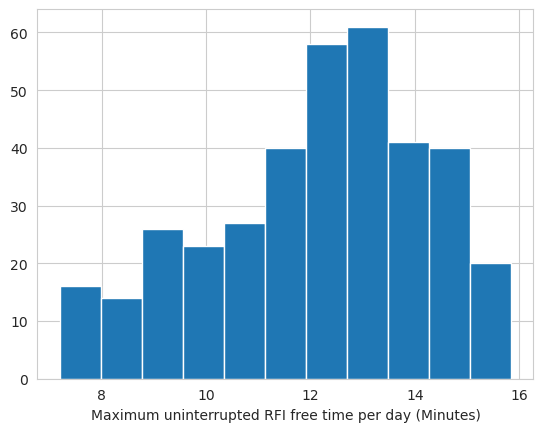

In [95]:
from src2.FDrule import FDrule
sns.set_style('whitegrid')
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/equi_unint.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [ ]:
# compare the two orbits:
plt.scatter(fomvals,FOMtime/3600,label='Equatorial',marker='*')
plt.scatter(fomvals,FOMtime1/3600,label='Polar',marker='D')
plt.ylabel('Time spent in hours')
plt.xlabel('FOM value')
# plt.xlim(left=10)
plt.legend()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/orbitcomp.pdf',dpi=600,bbox_inches='tight')
plt.show()

## Geosynchronous orbit

### Alt = 36000 km

In [ ]:
# FOM_map=np.zeros(hp.nside2npix(nside))
# for i in range(len(FOM_map)):
# 	num_of_rfi_chan=len(freq_range[power_output[2,i,:]!=0])
# 	rfi_band=0.244*num_of_rfi_chan 
# 	usable_band=tot_band-rfi_band
# 	FOM_map[i]+=usable_band

In [ ]:
# # open TLE archive
# file=open('../TLE_files/NSS.txt')
# content=file.read()
# ts = load.timescale()
# eph=load('de421.bsp')

In [ ]:
# lineone=[]
# linetwo=[]
# num=2000
# year=np.zeros(num)
# month=np.zeros(num)
# days=np.zeros((num))
# hour=np.zeros((num))
# minute=np.zeros((num))
# second=np.zeros((num))
# for i in range(2000):
#     line11=(content[((2*i)*70):((2*i)*70)+69])
#     line22=(content[((2*i+1)*70):((2*i+1)*70)+69])
#     sate=EarthSatellite(line11,line22,'Landsat7',ts)
# #     print(sate)
#     lineone.append(line11)
#     linetwo.append(line22)
#     year=sate.epoch.utc.year
#     month=sate.epoch.utc.month
#     day=sate.epoch.utc.day
#     days[i]+=day
#     if year==1999.0:
#         if month==11.0:
#             if day==20.0:
#                    break
    
    
    

In [ ]:
# uniq_idx=[]
# for i in range(len(lineone)):
#     if i>0:
#         if days[i]!=days[i-1]:
#             uniq_idx.append(i)
        
   

In [ ]:
# subpoints=[]
# sunlit=[]
# t11=[]
# for idx,i in enumerate(uniq_idx):
#     if idx==0:
#         line1=lineone[i]
#         line2=linetwo[i]
#         satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
#         print(satellite)
#         tz = pytz.timezone('UTC')
#         st=satellite.epoch.utc
#         dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
#         t0 = ts.utc(dt)
#         t1 = ts.utc(dt + relativedelta(hours=24))
#         t11.append(t1)
#         timescales = ts.linspace(t0,t1, 10000)

#         geocentrics = satellite.at(timescales)
#         sunlit.append(geocentrics.is_sunlit(eph))
#         subpoints.append(wgs84.subpoint_of(geocentrics))
#     else:
#         line1=lineone[i]
#         line2=linetwo[i]
#         satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
#         print(satellite)
#         tz = pytz.timezone('UTC')
#         st=t11[idx-1].utc
#         dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
#         t0 = ts.utc(dt)
#         t1 = ts.utc(dt + relativedelta(hours=24))
#         t11.append(t1)
#         timescales = ts.linspace(t0,t1, 10000)

#         geocentrics = satellite.at(timescales)
#         sunlit.append(geocentrics.is_sunlit(eph))
#         subpoints.append(wgs84.subpoint_of(geocentrics))

    

In [ ]:
# year_lon=[]
# year_lat=[]
# for i in range(len(subpoints)):
#     year_lon.append(subpoints[i].longitude.degrees)
#     year_lat.append(subpoints[i].latitude.degrees)

In [ ]:
# sunlit=np.array(sunlit)
# year_lon=np.array(year_lon)
# year_lat=np.array(year_lat)

In [ ]:
# year_lon=year_lon[:201,:]
# year_lat=year_lat[:201,:]

In [ ]:
# FOMtime1=np.zeros(55)
# for i in range(len(year_lat)):
#     for j in range(len(year_lat[0])):
#         orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
#         fomval=int(FOM_map[orbpix])
#         if sunlit[i,j]==True:
#             FOMtime1[fomval]+=0
#         else:
#             FOMtime1[fomval]+=deltaT

In [ ]:
# plt.scatter(fomvals,FOMtime1)
# plt.show()

In [ ]:
# np.max(power_output[2,:,:])

In [ ]:
# OWFOM=np.zeros(hp.nside2npix(nside))
# time=np.zeros(np.shape(OWFOM))
# for i in year_lat:
#     for j in year_lon:
#         pix=hp.ang2pix(nside,j,i,lonlat=True)
#         OWFOM[pix]+=FOM_map[pix]
#         time[pix]+=1
        

In [ ]:
# hp.mollview(time,flip='geo',norm='hist',cmap='gnuplot2')
# plt.show()

## one day slice 

In [ ]:
# point=[]
# for i in range(len(year_lat)): # i is one day
#     foms=[]
#     for j in range(len(year_lat[0])): # j is a point in a day of OP
#         if sunlit[i,j]==False:
#             orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
#             fomval=int(FOM_map[orbpix])
#             foms.append(fomval) # record FOM at each point of OP for one day
#             count=0 # set count to 0
#             valz=[] # list to which uninterrupted 54 FOM times will be appended.
#             for k in range(len(foms)): # loop through each fom val per day (10000 vals)
#                 if foms[k]>=thresholdFOM:
#                     count+=1 # count gets +1 if FOM is 54.
#                 else:
#                     valz.append(count*(deltaT/60)) # if FOM changes, it appends uninterrupted time and resets count
#                     count=0                        # to 0.
#     print(f'There is a maximum of {max(valz)} minutes of uninterrupted 55FOM on this day {sum(valz)}') # print max uninterrupted time.

## RFI temp heatmap

In [ ]:
freq_range[144]

In [ ]:
hp.mollview(FOM_map,flip='geo')

In [ ]:
test_plot1 = np.zeros(hp.nside2npix(nside)) 
test_plot1[0:np.size(power_output[1,:,0])] = power_output[1,:,54]
hp.mollview(test_plot1,cmap='plasma',unit="in Kelvin",norm='hist',flip='geo',format= '%.8e')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/RFI_latestHM.pdf')
plt.show()

In [ ]:
powercube_df=pd.DataFrame(power_output[1,:,:])
# powercube_df.to_csv('/home/saurabhs/Documents/Yogen_starfire/noSynth705.csv')

In [ ]:
np.where(power_output[:,:,])